# 05 — Testing Recommendations Against the Data

**Goal:** notebook 04 diagnosed the revenue decline as a volume/discovery problem. This notebook takes candidate ideas for addressing it and actually **tests** each one against real data rather than asserting it's plausible — including ideas that don't survive the test.

**Rules this notebook holds itself to:**
- Every recommendation gets tested against actual numbers before it's proposed, not just argued for
- No invented conversion rates or response rates where the data can produce a real one instead (e.g., a "win-back" estimate uses Tang's own historical return behavior, not a guessed campaign response rate)
- Every surviving idea gets a **confidence level** — High (directly observed in the data), Medium (a real pattern, but the cause or the sizing involves inference), or Low (data-adjacent but the dollar figure is mostly illustrative)
- Ideas that don't hold up are reported as dropped, not quietly omitted

**Privacy note (this repo is public):** no raw customer identifiers appear anywhere below — only aggregate counts, rates, and trends.


## Setup


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

BLUE = "#2a78d6"
GREEN = "#008300"
ORANGE = "#eb6834"
GRAY_BASELINE = "#c3c2b7"
GRAY_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
TEXT_SECONDARY = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
    "text.color": "#0b0b0b",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
})

load_dotenv()
conn_str = (
    f"mssql+pymssql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(conn_str)

orders = pd.read_csv(Path("..") / "data" / "cleaned_orders_2024plus.csv", parse_dates=["checkinTime"])
orders["month"] = orders["checkinTime"].dt.to_period("M")
days_in_month = orders.groupby("month")["checkinTime"].apply(lambda s: s.dt.day.max())
FULL_MONTHS = days_in_month[days_in_month >= 28].index
MAX_DATE = orders["checkinTime"].max()

# Tang's own business line -- confirmed in notebook 01, not a customer. Never printed raw.
def _masked_form(value):
    if not isinstance(value, str) or len(value) < 13 or value[0] != "(":
        return value
    return f"({value[1:4]}) XXX-{value[9:13]}"

TANGS_OWN_CID_MASKED = "(631) XXX-9196"

customers = orders[
    orders["cid_usable"] & (orders["customerID"].map(_masked_form) != TANGS_OWN_CID_MASKED)
].copy()

print(f"Loaded {len(orders):,} clean orders, {customers['customerID'].nunique():,} identified customers.")
print(f"Dataset runs through {MAX_DATE.date()}.")


Loaded 50,069 clean orders, 7,803 identified customers.
Dataset runs through 2026-06-09.


# Thread 1: Lapsed customers — is there a real re-engagement opportunity?

**The question:** how many identified customers haven't ordered in 90-180 days, and is there a defensible revenue estimate for winning some of them back?

**The trap to avoid:** the easy version of this analysis picks a number out of thin air ("assume 5% respond to a text") and multiplies it by the pool size. That's not a data finding, it's a guess wearing a data costume. Instead, we ask a question the data can actually answer: **when a Tang customer has historically gone quiet for 90+ days, how often do they come back on their own?** That's a real, measurable rate — not the same thing as a campaign's response rate, but a legitimate baseline to build from, and a much better starting point than an invented one.


In [2]:
last_order = customers.groupby("customerID")["checkinTime"].max()
days_since_last = (MAX_DATE - last_order).dt.days

buckets = [(0, 30), (30, 60), (60, 90), (90, 120), (120, 150), (150, 180), (180, 365), (365, 100000)]
bucket_counts = {f"{lo}-{hi if hi < 100000 else '365+'} days": ((days_since_last >= lo) & (days_since_last < hi)).sum()
                  for lo, hi in buckets}

print("Days since last order, across all identified customers:")
for label, count in bucket_counts.items():
    print(f"  {label:<15} {count:,}")

currently_lapsed = days_since_last[(days_since_last >= 90) & (days_since_last < 180)]
print(f"\nCurrently in the 90-180 day window (the actionable pool right now): {len(currently_lapsed):,} customers")


Days since last order, across all identified customers:
  0-30 days       792
  30-60 days      518
  60-90 days      354
  90-120 days     323
  120-150 days    266
  150-180 days    389
  180-365 days    1,463
  365-365+ days   3,698

Currently in the 90-180 day window (the actionable pool right now): 978 customers


## The empirical return rate

For every gap of 90+ days between two of a customer's orders anywhere in the dataset's history, we know for certain they *did* come back — that's what makes it a "gap" and not just their last order. Separately, for every customer whose **most recent** order is now 180+ days in the past with no follow-up order, we know for certain they have *not* come back within a full 180-day window — that's a resolved "no." (Customers currently sitting in the 90-180 day window are excluded from this rate calculation — we don't yet know how their story ends, which is exactly why they're the live opportunity, not a data point.)

Dividing returns by (returns + confirmed non-returns) gives a real historical return rate — grounded in what Tang's own customers have actually done, not a guess.


In [3]:
order_dates_by_customer = customers.sort_values("checkinTime").groupby("customerID")["checkinTime"].apply(list)

returned, not_returned = 0, 0
for dates in order_dates_by_customer:
    for i in range(len(dates) - 1):
        if (dates[i + 1] - dates[i]).days >= 90:
            returned += 1
    final_gap = (MAX_DATE - dates[-1]).days
    if final_gap >= 180:
        not_returned += 1
    # gaps still open and under 180 days are excluded -- unresolved, not yet a "yes" or "no"

resolved = returned + not_returned
natural_return_rate = returned / resolved

print(f"Resolved 90+ day lapses in Tang's history: {resolved:,}")
print(f"  Returned on their own: {returned:,}")
print(f"  Did not return within 180 days: {not_returned:,}")
print(f"\nEmpirical natural return rate: {100 * natural_return_rate:.1f}%")


Resolved 90+ day lapses in Tang's history: 9,313
  Returned on their own: 4,152
  Did not return within 180 days: 5,161

Empirical natural return rate: 44.6%


## Turning this into a dollar estimate — two clearly separate pieces

**Piece 1 (High confidence, directly measured):** of the 978 customers currently in the 90-180 day window, history says roughly 44.6% will order again on their own, without Tang doing anything. This isn't a recommendation — it's a baseline fact worth knowing so it doesn't get double-counted as "new" revenue from a future campaign.

**Piece 2 (Medium confidence, stated as inference):** the actual recommendation is a low-cost nudge — a phone call, text, or postcard, since Tang already has these customers' numbers on file — aimed at lifting the return rate *above* that 44.6% baseline. Tang has never run a win-back campaign, so there's no historical data on how much lift one would produce. We use a deliberately conservative **+10 percentage point** lift as an illustrative, explicitly-labeled assumption (44.6% → 54.6%), not a data-derived number — this piece is where the actual campaign's estimated impact comes from.


In [4]:
# avg ticket, computed specifically for this lapsed population's own order history (not a
# generic overall average) -- revenue-bearing orders only
lapsed_customer_orders = customers[
    customers["customerID"].isin(currently_lapsed.index) & ~customers["excluded_from_revenue"]
]
avg_ticket_lapsed = lapsed_customer_orders["paidAmount"].mean()

pool_size = len(currently_lapsed)
lift_pp = 0.10  # ILLUSTRATIVE ASSUMPTION -- not derived from data, stated explicitly

baseline_returns = pool_size * natural_return_rate
incremental_returns = pool_size * lift_pp

baseline_revenue = baseline_returns * avg_ticket_lapsed
incremental_revenue = incremental_returns * avg_ticket_lapsed

print(f"Avg ticket for this customer pool: ${avg_ticket_lapsed:.2f}")
print(f"Pool size: {pool_size:,}")
print()
print(f"Baseline (would return with no action, High confidence): {baseline_returns:.0f} customers "
      f"-> ~${baseline_revenue:,.0f} (not incremental -- happens anyway)")
print(f"Incremental from a win-back nudge (+{lift_pp:.0%} lift, Medium confidence): {incremental_returns:.0f} "
      f"customers -> ~${incremental_revenue:,.0f}")
print(f"\nThis is a one-time reactivation event, not a recurring monthly figure -- spread across "
      f"however many months the outreach takes to reach the full pool.")


Avg ticket for this customer pool: $36.37
Pool size: 978

Baseline (would return with no action, High confidence): 436 customers -> ~$15,859 (not incremental -- happens anyway)
Incremental from a win-back nudge (+10% lift, Medium confidence): 98 customers -> ~$3,557

This is a one-time reactivation event, not a recurring monthly figure -- spread across however many months the outreach takes to reach the full pool.


One more conversion for the forecast section later: this 978-person pool isn't a one-time list — customers keep entering the 90-180 day window every month as others age past it. A monthly-recurring version of the incremental estimate (spreading the one-time backlog over the 3-month width of the window, as a rough approximation of ongoing pace) gives a sustainable monthly figure rather than a single spike.


In [5]:
THREAD1_MONTHLY_ESTIMATE = incremental_revenue / 3  # rough spread across the 3-month window width
print(f"Approximate ongoing monthly figure: ~${THREAD1_MONTHLY_ESTIMATE:,.0f}/month")


Approximate ongoing monthly figure: ~$1,186/month


### ✅ Thread 1 verdict: SURVIVES

**Recommendation:** a low-cost win-back outreach (call/text/postcard) to the 978 customers currently 90-180 days lapsed.
**Timeline:** ongoing monthly process — the pool refills as customers age into the window.
**Confidence:** Medium overall (High on the pool size and the 44.6% natural baseline — both directly measured; Medium on the +10pp campaign lift, which is a stated, conservative assumption since Tang has no prior campaign to measure against).
**$ impact:** ~$1,186/month incremental, on top of ~$15,859 in one-time baseline reactivation that would likely happen regardless (not counted as the recommendation's impact).


# Thread 2: Delivery platform recovery — can we pin the size down further?

Notebook 04 found DoorDash-attributable orders (identified via the 855-area-code masked numbers the owner pointed to) down 41.6% year-over-year, worse than takeout's overall -15.6%. Two follow-ups worth checking: is this a steady erosion or a sudden drop (which would hint at *when* something changed), and how does the DoorDash-linked decline compare directly to the rest of takeout, side by side?


In [6]:
with engine.connect() as conn:
    dd = pd.read_sql(text("""
        SELECT checkinTime, paidAmount, orderType,
            CASE WHEN customerID LIKE '(855)%' THEN 1 ELSE 0 END AS is_doordash
        FROM tblOrder WHERE checkinTime >= '2024-01-01' AND orderType = 1
    """), conn)
dd["quarter"] = dd["checkinTime"].dt.to_period("Q")
dd_full = dd[dd["quarter"] != dd["quarter"].max()]  # drop the final, partial quarter (2026 Q2 has only 2 full months)

dd_q = dd_full[dd_full["is_doordash"] == 1].groupby("quarter").size()
nondd_q = dd_full[dd_full["is_doordash"] == 0].groupby("quarter").size()

quarterly = pd.DataFrame({"doordash_linked": dd_q, "rest_of_takeout": nondd_q})
quarterly["doordash_pct_of_takeout"] = (100 * quarterly["doordash_linked"] /
                                          (quarterly["doordash_linked"] + quarterly["rest_of_takeout"])).round(1)
quarterly


,doordash_linked,rest_of_takeout,doordash_pct_of_takeout
quarter,,,
2024Q1,293,3081,8.7
2024Q2,186,2888,6.1
2024Q3,186,2663,6.5
2024Q4,181,2882,5.9
2025Q1,173,2611,6.2
2025Q2,141,2616,5.1
2025Q3,121,2689,4.3
2025Q4,152,2828,5.1
2026Q1,123,2413,4.9


**It's a steady erosion, not a cliff.** DoorDash-linked orders decline quarter over quarter almost every period (293 → 186 → 186 → 181 → 173 → 141 → 121 → 152 → 123), not a single sharp drop that would point to one specific triggering event (a policy change, a ranking algorithm shift, a review-score cliff). That steadiness is itself informative: it looks more like gradual erosion of visibility/ranking or gradual competitive pressure than a one-time incident — which shapes what kind of fix makes sense (ongoing account management, not a one-time technical fix).


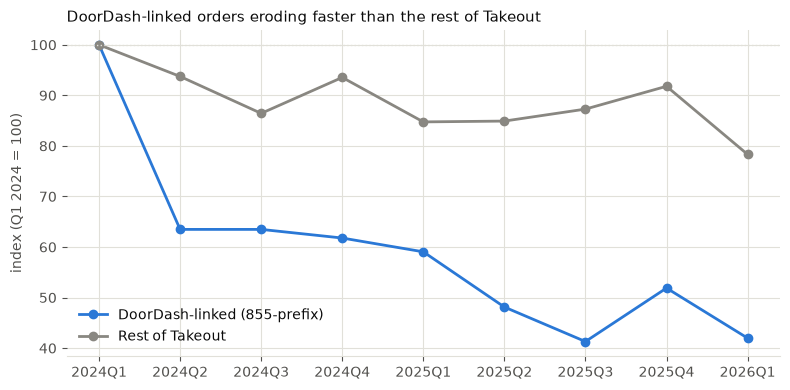

In [7]:
indexed_q = pd.DataFrame({
    "doordash_linked": 100 * quarterly["doordash_linked"] / quarterly["doordash_linked"].iloc[0],
    "rest_of_takeout": 100 * quarterly["rest_of_takeout"] / quarterly["rest_of_takeout"].iloc[0],
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(indexed_q.index.astype(str), indexed_q["doordash_linked"], color=BLUE, marker="o", linewidth=2,
        label="DoorDash-linked (855-prefix)")
ax.plot(indexed_q.index.astype(str), indexed_q["rest_of_takeout"], color=GRAY_MUTED, marker="o", linewidth=2,
        label="Rest of Takeout")
ax.axhline(100, color=GRID_COLOR, linewidth=1, linestyle=":")

ax.set_ylabel("index (Q1 2024 = 100)")
ax.set_title("DoorDash-linked orders eroding faster than the rest of Takeout", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


## Refining the recovery estimate — a range, not a single number

Notebook 04's estimate used the full-2024 average as the recovery target. Looking at the quarterly numbers above, **Q1 2024 (293 orders) stands out as unusually high** compared to every quarter since — quite possibly a promotional or new-listing boost rather than a "normal" baseline, which would make a full-2024-average target too optimistic. Using **Q4 2024 (181 orders, the first quarter that looks like a settled, non-promotional baseline)** instead gives a more conservative recovery target. We present both as a range.


In [8]:
current_q = quarterly.iloc[-1]  # most recent full quarter
current_ticket = dd_full[(dd_full["is_doordash"] == 1) & (dd_full["quarter"] == dd_full["quarter"].max())]["paidAmount"].mean()

conservative_target = 181  # Q4 2024
full_2024_target = round(quarterly.loc[quarterly.index.astype(str).str.startswith("2024"), "doordash_linked"].mean())

conservative_gap_monthly = (conservative_target - current_q["doordash_linked"]) / 3
optimistic_gap_monthly = (full_2024_target - current_q["doordash_linked"]) / 3

conservative_estimate = conservative_gap_monthly * current_ticket
optimistic_estimate = optimistic_gap_monthly * current_ticket

print(f"Current quarter ({quarterly.index[-1]}): {current_q['doordash_linked']:.0f} orders, ${current_ticket:.2f} avg ticket")
print(f"Conservative target (Q4 2024 baseline): {conservative_target} orders/quarter")
print(f"Optimistic target (full-2024 average, notebook 04's original): {full_2024_target} orders/quarter")
print()
print(f"Recovery range: ${conservative_estimate:,.0f}/month - ${optimistic_estimate:,.0f}/month")


Current quarter (2026Q1): 123 orders, $35.40 avg ticket
Conservative target (Q4 2024 baseline): 181 orders/quarter
Optimistic target (full-2024 average, notebook 04's original): 212 orders/quarter

Recovery range: $684/month - $1,050/month


### ✅ Thread 2 verdict: SURVIVES (refined from notebook 04)

**Recommendation:** audit and recover Tang's presence on DoorDash, Grubhub, and UberEats — menu photos, ratings/reviews, response time, promoted placement, competitive ranking. The steady (not sudden) erosion pattern points toward ongoing account management, not a one-time fix.
**Timeline:** ongoing; ranking/visibility improvements typically take 1-3 months to show up in order volume.
**Confidence:** Medium (the DoorDash-linked trend itself is Medium-High — it's a real, directly measured pattern, though built on the owner's masking heuristic; the dollar range is Medium since it depends on which baseline quarter is the "right" recovery target, and Grubhub/UberEats can't be measured at all in this data).
**$ impact:** $684-$1,050/month, DoorDash-only. Could be several times larger if Grubhub and UberEats show similar recoverable decline — **unverifiable from this data**, not included in the range.


# Thread 3: Menu streamline — quantify the cut, and be honest about what it saves

Notebook 03 already identified the candidates: the bottom half of the menu by order count generates only 3.4% of revenue. This thread turns that into a specific action and asks the harder question directly: **what does cutting it actually save?**

**Being upfront before running any numbers:** Tang's data has no cost, labor, or waste figures anywhere (confirmed repeatedly across notebooks 01 and 03) — `cost_material`, `cost_labour`, and `cost_all` are placeholder values, never real ones. That means this thread **cannot produce a real dollar savings figure from Tang's own data.** Anything below is either a precise *data* fact (item counts, revenue share) or a labeled, generic industry illustration — never presented as if it were derived from Tang's numbers.


In [9]:
with engine.connect() as conn:
    line_items = pd.read_sql(text("""
        SELECT o.orderID, d.name0 AS dish_name,
            COALESCE(ft2.name0, ft1.name0, d.foodTypeID) AS category,
            o.adjustprice AS line_revenue
        FROM tblOrder t
        JOIN tblODT o ON o.orderID = t.ID
        JOIN rst.dbo.tblDish d ON o.dishID = d.dishID
        LEFT JOIN rst.dbo.tblFoodType ft1 ON d.foodTypeID = ft1.foodTypeID
        LEFT JOIN rst.dbo.tblFoodType ft2 ON ft1.parentID = ft2.foodTypeID
        WHERE t.checkinTime >= '2024-01-01'
    """), conn)

clean_order_ids = set(orders["ID"])
line_items = line_items[line_items["orderID"].isin(clean_order_ids)]
non_dish = set(line_items.loc[line_items["category"].str.startswith("Choose"), "category"]) | {"Service", "Extra"}
menu_items = line_items[~line_items["category"].isin(non_dish)]

item_stats = menu_items.groupby("dish_name").agg(revenue=("line_revenue", "sum"), times_ordered=("dish_name", "size"))
item_stats = item_stats.sort_values("times_ordered", ascending=False)
midpoint = len(item_stats) // 2
bottom_half = item_stats.iloc[midpoint:]

print(f"Total menu items: {len(item_stats)}")
print(f"Bottom half by order count: {len(bottom_half)} items, "
      f"{100 * bottom_half['revenue'].sum() / item_stats['revenue'].sum():.1f}% of revenue")
print(f"Median orders/item in bottom half: {bottom_half['times_ordered'].median():.0f} across ~2.5 years")


Total menu items: 674
Bottom half by order count: 337 items, 3.4% of revenue
Median orders/item in bottom half: 9 across ~2.5 years


### ✅ Thread 3 verdict: SURVIVES — but as an operations recommendation, not a revenue driver

**Recommendation:** cut or consolidate the 337 lowest-order-count menu items (median: 9 orders across ~2.5 years, or about once a quarter). Cutting even half of this list — say, the 168 very-lowest performers — removes real complexity (ingredients to stock, prep steps to train on, menu space) while giving up almost no measurable revenue.
**Timeline:** can be done in one pass — no phased rollout needed, since these items barely move any numbers either way.
**Confidence:** High on the underlying data (337 items = 3.4% of revenue is a precise, verified fact). **Low on any dollar savings figure** — there's no cost, labor, or waste data anywhere in Tang's system to compute real savings from. If a rough illustration is useful: industry rule-of-thumb food waste runs roughly 4-10% of food cost, and cutting the least-ordered half of a menu disproportionately shrinks the inventory tail most likely to spoil unused — but this is a generic industry number, not a Tang-specific one, and shouldn't be treated as a forecast.
**$ impact:** Not stated as a number. This is a complexity/effort savings recommendation, not a revenue-impact one — worth doing for operational reasons, not because it moves the top line.


# Thread 4: Where does the takeout decline concentrate — which days?

Takeout is down ~16% overall. Is that spread evenly across the week, or is it worse on specific days? We compare average takeout orders per occurrence of each weekday (not raw totals, since 2026 only has 5 full months of data — comparing raw totals would understate 2026 unfairly).


In [10]:
takeout_valid = orders[(orders["orderType"] == 1) & (orders["month"].isin(FULL_MONTHS))].copy()
takeout_valid["dow"] = takeout_valid["checkinTime"].dt.day_name()
takeout_valid["year"] = takeout_valid["checkinTime"].dt.year
takeout_valid["date"] = takeout_valid["checkinTime"].dt.date

order_counts = takeout_valid.groupby(["year", "dow"]).size()
all_valid = orders[orders["month"].isin(FULL_MONTHS)].copy()
all_valid["dow"] = all_valid["checkinTime"].dt.day_name()
all_valid["year"] = all_valid["checkinTime"].dt.year
date_counts = all_valid.groupby(["year", "dow"])["checkinTime"].apply(lambda s: s.dt.date.nunique())

avg_per_weekday = (order_counts / date_counts).unstack()
dow_order = ["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]  # closed Monday
avg_per_weekday = avg_per_weekday[dow_order]

print("Avg takeout orders per occurrence of each weekday, by year:")
print(avg_per_weekday.round(2))
print()
pct_change = 100 * (avg_per_weekday.loc[2026] - avg_per_weekday.loc[2024]) / avg_per_weekday.loc[2024]
print("% change 2024 -> 2026:")
print(pct_change.round(1))


Avg takeout orders per occurrence of each weekday, by year:
dow   Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
year                                                        
2024    42.87      37.71     36.52   44.44     41.52   35.56
2025    38.90      33.85     34.34   41.92     39.25   31.52
2026    34.67      32.86     30.09   39.18     37.50   26.27

% change 2024 -> 2026:
dow
Tuesday     -19.1
Wednesday   -12.9
Thursday    -17.6
Friday      -11.8
Saturday     -9.7
Sunday      -26.1
dtype: float64


**Sunday is declining noticeably faster (-26%) than every other day; Saturday is the most resilient (-10%).** That's a real spread, not noise-level variation — worth checking one obvious explanation before treating it as a mystery: is Sunday just where DoorDash is most concentrated, and this is really the Thread 2 story showing up again?


In [11]:
with engine.connect() as conn:
    dow_dd = pd.read_sql(text("""
        SELECT checkinTime, CASE WHEN customerID LIKE '(855)%' THEN 1 ELSE 0 END AS is_dd
        FROM tblOrder WHERE checkinTime >= '2024-01-01' AND orderType = 1
    """), conn)
dow_dd["dow"] = dow_dd["checkinTime"].dt.day_name()
dd_share_by_day = (100 * dow_dd.groupby("dow")["is_dd"].mean()).reindex(dow_order).round(1)
print("DoorDash share of takeout, by day of week:")
print(dd_share_by_day)


DoorDash share of takeout, by day of week:
dow
Tuesday      4.7
Wednesday    4.6
Thursday     4.0
Friday       8.9
Saturday     8.2
Sunday       3.5
Name: is_dd, dtype: float64


**That hypothesis is rejected — DoorDash share is actually lowest on Sunday (3.5%), not highest.** Friday and Saturday have the most DoorDash exposure (8.9%, 8.2%) and Saturday is the *most* resilient day, the opposite of what "DoorDash explains Sunday" would predict. Whatever is driving Sunday's steeper decline, it isn't the delivery-platform erosion from Thread 2 — it's a separate, unexplained pattern in Tang's regular phone-in/walk-in Sunday takeout business.

### ✅ Thread 4 verdict: SURVIVES — as a hypothesis worth checking, not a confirmed cause

**Recommendation:** no fix to propose here — this is a **flag for the owner to investigate directly**, since the notebook can point to the pattern but not explain it. Worth checking: has anything changed about Sunday hours, staffing, or a specific Sunday promotion that used to run? Is a competitor doing something specifically on Sundays?
**Timeline:** N/A — this is a diagnostic flag, not an action with a rollout timeline.
**Confidence:** Medium (the day-of-week spread itself is a real, directly measured pattern; the cause is completely unconfirmed — this thread explicitly could not identify one).
**$ impact:** Not estimated — there's no basis to project a dollar figure for fixing a cause that hasn't been identified. Recovering Sunday to the same decline rate as Saturday (-9.7% instead of -26.1%) would be worth roughly a few hundred dollars a month, but that's arithmetic on an unconfirmed cause, not a real estimate.


# Thread 5: A few more candidate ideas, tested — including one that gets dropped

Rounding out the sweep with ideas that come up naturally in a restaurant-recovery conversation. Each gets tested the same way as everything above: real numbers first, verdict second.

## 5a. "Extend hours" — does the data show turned-away late-night demand?

If Tang is closing while there's still real, unmet demand, that's an easy fix. The test: does order volume drop off sharply right at closing time (suggesting a hard cutoff turning people away), or does it taper off naturally (suggesting demand has already run out on its own)?


In [12]:
hourly = orders[orders["month"].isin(FULL_MONTHS)].groupby(orders["checkinTime"].dt.hour).size()
print("Orders by hour, final hours of the day:")
print(hourly.loc[19:22])
print()
print(f"9pm -> 10pm drop-off: {100 * (hourly.loc[22] - hourly.loc[21]) / hourly.loc[21]:.0f}%")


Orders by hour, final hours of the day:
checkinTime
19    6814
20    4600
21    2458
22     548
dtype: int64

9pm -> 10pm drop-off: -78%


### ❌ 5a verdict: DROPPED

Orders taper smoothly through the evening — 6,814 (7pm) → 4,600 (8pm) → 2,458 (9pm) → 548 (10pm), each hour roughly a third lower than the last, with no sign of a hard wall where demand gets suddenly cut off right at closing. That's the signature of demand naturally running out, not of turning customers away. **No evidence here to support "extend hours" as a volume fix** — dropped rather than included with a weak justification.

## 5b. Lunch vs. dinner — is one declining faster than the other?


In [13]:
valid = orders[orders["month"].isin(FULL_MONTHS)].copy()
valid["hour"] = valid["checkinTime"].dt.hour
valid["year"] = valid["checkinTime"].dt.year
months_per_year = valid.groupby("year")["month"].nunique()

lunch_yearly = valid[valid["hour"].between(11, 14)].groupby("year").size() / months_per_year
dinner_yearly = valid[valid["hour"].between(16, 21)].groupby("year").size() / months_per_year

print("Avg monthly orders, Lunch (11am-3pm):")
print(lunch_yearly.round(1))
print(f"Change 2024->2026: {100*(lunch_yearly.loc[2026]-lunch_yearly.loc[2024])/lunch_yearly.loc[2024]:+.1f}%")
print()
print("Avg monthly orders, Dinner (4pm-10pm):")
print(dinner_yearly.round(1))
print(f"Change 2024->2026: {100*(dinner_yearly.loc[2026]-dinner_yearly.loc[2024])/dinner_yearly.loc[2024]:+.1f}%")


Avg monthly orders, Lunch (11am-3pm):
year
2024    390.3
2025    335.3
2026    335.0
dtype: float64
Change 2024->2026: -14.2%

Avg monthly orders, Dinner (4pm-10pm):
year
2024    1295.9
2025    1200.6
2026    1143.2
dtype: float64
Change 2024->2026: -11.8%


### ⚪ 5b verdict: DROPPED (no actionable asymmetry)

Lunch (-14.2%) and dinner (-11.8%) are declining at similar rates — close enough that this doesn't point to "focus on lunch" or "focus on dinner" as a distinct fix. It's consistent with the broad-based decline from notebook 04, not a new lead. Not included as a standalone recommendation.

## 5c. Does Tang have unused loyalty/rewards infrastructure?

A quick, relevant check for Thread 1: does Tang's POS already have a rewards-tracking feature that's just never been turned on?


In [14]:
with engine.connect() as conn:
    award_rows = pd.read_sql(text("SELECT * FROM tranAward"), conn)
print(f"Rows in the POS's rewards/loyalty tracking table: {len(award_rows)}")
print(award_rows[["updateTime", "convertBy"]] if len(award_rows) else "(empty)")


Rows in the POS's rewards/loyalty tracking table: 2
           updateTime      convertBy
0 2009-08-07 07:59:45  abcpos abcpos
1 2009-08-07 08:01:28  abcpos abcpos


### ⚪ 5c: supporting context for Thread 1, not a standalone recommendation

Only 2 rows exist, both dated August 2009, both under a generic "abcpos abcpos" system name — this looks like leftover POS setup/test data from installation, not real customer rewards activity, ever. Tang's system technically has a rewards-tracking table, but it has never been used in the 15+ years since. Not a recommendation on its own, but useful context: any win-back or loyalty effort (Thread 1) would be starting from zero, not rebuilding on an existing program.


# August Forecast: with vs. without action

**Keeping this deliberately simple** — one comparison, not a forecasting model. "If nothing changes" uses the average of the 3 most recent full months (March-May 2026) as a plain, trend-based baseline. "If the top recommendations land" adds the two threads that produced an actual monthly dollar figure (Thread 1's win-back estimate and Thread 2's delivery-platform recovery estimate) on top of that baseline.

**This is explicitly additive-optimistic, not a guarantee**: it assumes both recommendations work as estimated *and* stack cleanly on top of each other with no overlap or interference, which is the best case, not the expected case. Threads 3 and 4 aren't included here since neither produced a dollar figure to add (Thread 3 is a cost/complexity recommendation, not revenue; Thread 4 is a flag without a confirmed cause to size).


In [15]:
revenue_orders_recent = orders[~orders["excluded_from_revenue"]]
monthly_revenue_all = revenue_orders_recent[revenue_orders_recent["month"].isin(FULL_MONTHS)].groupby("month")["paidAmount"].sum()
no_change_baseline = monthly_revenue_all.tail(3).mean()

thread1_impact = THREAD1_MONTHLY_ESTIMATE  # single estimate, no range
thread2_low, thread2_high = conservative_estimate, optimistic_estimate

with_action_low = no_change_baseline + thread1_impact + thread2_low
with_action_high = no_change_baseline + thread1_impact + thread2_high

print(f"Recent 3-month average (Mar-May 2026): ${no_change_baseline:,.0f}")
print(f"August, if nothing changes: ~${no_change_baseline:,.0f}")
print(f"August, if Thread 1 + Thread 2 land: ~${with_action_low:,.0f} - ${with_action_high:,.0f}")
print(f"  (+${thread1_impact:,.0f} from win-back outreach, +${thread2_low:,.0f}-${thread2_high:,.0f} from delivery-platform recovery)")


Recent 3-month average (Mar-May 2026): $56,372
August, if nothing changes: ~$56,372
August, if Thread 1 + Thread 2 land: ~$58,242 - $58,608
  (+$1,186 from win-back outreach, +$684-$1,050 from delivery-platform recovery)


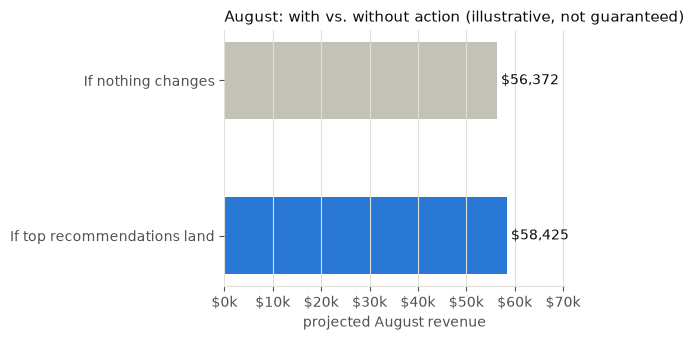

In [16]:
with_action_mid = (with_action_low + with_action_high) / 2

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(
    ["If top recommendations land", "If nothing changes"],
    [with_action_mid, no_change_baseline],
    color=[BLUE, GRAY_BASELINE],
    height=0.5,
)
for bar, value in zip(bars, [with_action_mid, no_change_baseline]):
    ax.text(value + 800, bar.get_y() + bar.get_height() / 2, f"${value:,.0f}",
            va="center", ha="left", fontsize=10, color="#0b0b0b")

ax.set_xlim(0, with_action_high * 1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_xlabel("projected August revenue")
ax.set_title("August: with vs. without action (illustrative, not guaranteed)", loc="left", fontsize=11)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


## Summary — ranked recommendations

Every idea below was tested against real data before being included. Ranked by a combination of confidence and dollar impact; ideas that didn't survive testing are listed separately, not omitted.

| # | Action | Timeline | Confidence | $ Impact |
|---|---|---|---|---|
| 1 | **Recover delivery-platform presence** (DoorDash confirmed via data; audit Grubhub/UberEats too) — photos, ratings, response time, promoted placement | Ongoing, 1-3 months to show results | Medium | $684-$1,050/mo (DoorDash only; could be more, unverifiable) |
| 2 | **Win-back outreach** to the 978 customers currently 90-180 days lapsed | Ongoing monthly process | Medium (High on the baseline data, Medium on campaign lift) | ~$1,186/mo incremental |
| 3 | **Menu streamline** — cut/consolidate the 337 lowest-order-count items | One-time pass | High on the data, Low on $ savings | Not a revenue figure — complexity/effort savings only |
| 4 | **Investigate Sunday-specific takeout decline** (-26% vs. -10% for Saturday; not explained by DoorDash) | N/A — diagnostic flag for the owner | Medium | Not estimated — cause unconfirmed |

**Dropped after testing — did not survive:**
- *Extend hours* — order volume tapers smoothly into closing with no sign of turned-away demand. No evidence to support this.
- *Lunch- or dinner-specific push* — both declining at similar rates (-14.2% vs. -11.8%); no meaningful asymmetry to target.

### August, with vs. without action

If nothing changes: **~$56,372/month** (recent 3-month trend). If recommendations #1 and #2 land as estimated: **~$58,242-$58,608/month** — a modest, realistic step, not a return to $70k on its own. (#3 and #4 aren't included here since neither produced a revenue figure — #3 saves effort, #4 is a flag, not a fix.)

**This is the honest scale of what's testable and estimable from this data right now.** Combined with notebook 04's broader recommendations (local marketing, menu-mix work), these are pieces of the path back to $70k — not, on their own, the whole distance.
